# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Asep Ridwan
- Email: asepnet93@gmail.com
- Id Dicoding: asepnet93 

## Persiapan

### Menyiapkan library yang dibutuhkan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


### Menyiapkan data yang akan diguankan

## Data Understanding

First 5 rows:
   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         122.0            1                     19   
1                         160.0            1                      1   
2                         122.0  

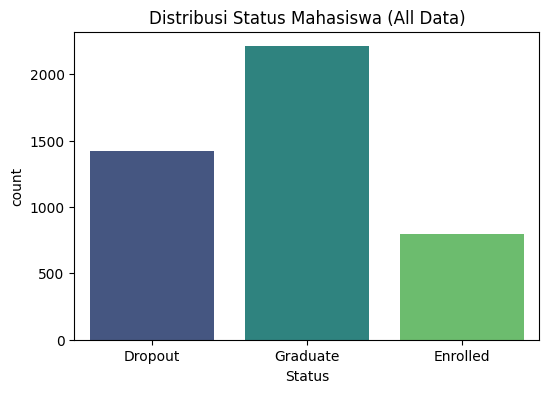

In [4]:
# ==================================================
# DATA UNDERSTANDING
# ==================================================

# Load dataset 
df = pd.read_csv('students_performance.csv', sep=';')

# Lihat 5 baris pertama
print("First 5 rows:")
print(df.head())

print("="*50)
print("DATA UNDERSTANDING")
print("="*50)

# 1. Info dataset
print("\n1. DATA INFO:")
print("-"*30)
print(df.info())

# 2. Cek missing values
print("\n2. MISSING VALUES:")
print("-"*30)
print(df.isnull().sum())

# 3. Statistik deskriptif
print("\n3. DESCRIPTIVE STATISTICS:")
print("-"*30)
print(df.describe())

# 4. Distribusi Target (Status)
print("\n4. TARGET DISTRIBUTION (Status):")
print("-"*30)
print(df['Status'].value_counts())

# 5. Visualisasi Distribusi Target (SEMUA data, termasuk Enrolled)
plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=df, palette='viridis')
plt.title('Distribusi Status Mahasiswa (All Data)')
plt.show()

## Data Preparation / Preprocessing

In [ ]:
print("="*50)
print("DATA PREPARATION")
print("="*50)

df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f"Data setelah filter (hanya Dropout & Graduate): {df_model.shape[0]} rows")

selected_features = [
    'Marital_status', 'Application_mode', 'Application_order', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade',
    'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
    'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment',
    'International', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP'
]

X = df_model[selected_features].copy()
y = df_model['Status'].copy()

le = LabelEncoder()
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl') 

# Membagi data Train (80%) dan Test (20%) dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Distribusi target di train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Distribusi target di test: {pd.Series(y_test).value_counts().to_dict()}")

DATA PREPARATION
Data setelah filter (hanya Dropout & Graduate): 3630 rows
Train size: 2904
Test size: 726
Distribusi target di train: {'Graduate': 1767, 'Dropout': 1137}
Distribusi target di test: {'Graduate': 442, 'Dropout': 284}


## Modeling

In [6]:
print("="*50)
print("MODELING")
print("="*50)

# Train Random Forest Classifier  
rf = RandomForestClassifier(
    n_estimators=200,        
    max_depth=15,            
    min_samples_split=10,    
    min_samples_leaf=5,      
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Prediksi data test
y_pred = rf.predict(X_test)

print("Model trained successfully!")

# Simpan model ke file .pkl
joblib.dump(rf, 'model_rf.pkl')
print("Model saved as 'model_rf.pkl'")

MODELING
Model trained successfully!
Model saved as 'model_rf.pkl'


## Evaluation

EVALUATION

1. CLASSIFICATION REPORT:
------------------------------
              precision    recall  f1-score   support

     Dropout       0.89      0.79      0.84       284
    Graduate       0.87      0.94      0.90       442

    accuracy                           0.88       726
   macro avg       0.88      0.86      0.87       726
weighted avg       0.88      0.88      0.88       726


2. CONFUSION MATRIX:
------------------------------
[[224  60]
 [ 28 414]]


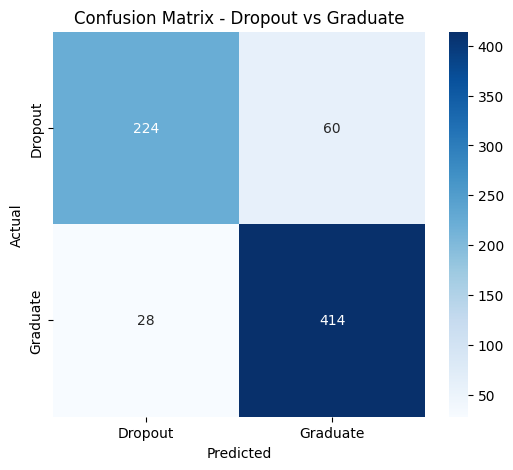


3. FEATURE IMPORTANCE:
------------------------------
                           Feature  Importance
20  Curricular_units_2nd_sem_grade    0.334879
19  Curricular_units_1st_sem_grade    0.185855
14         Tuition_fees_up_to_date    0.101527
17               Age_at_enrollment    0.055718
3                           Course    0.047302
16              Scholarship_holder    0.035124
10                 Admission_grade    0.034987
13                          Debtor    0.034134
1                 Application_mode    0.031358
6     Previous_qualification_grade    0.029040


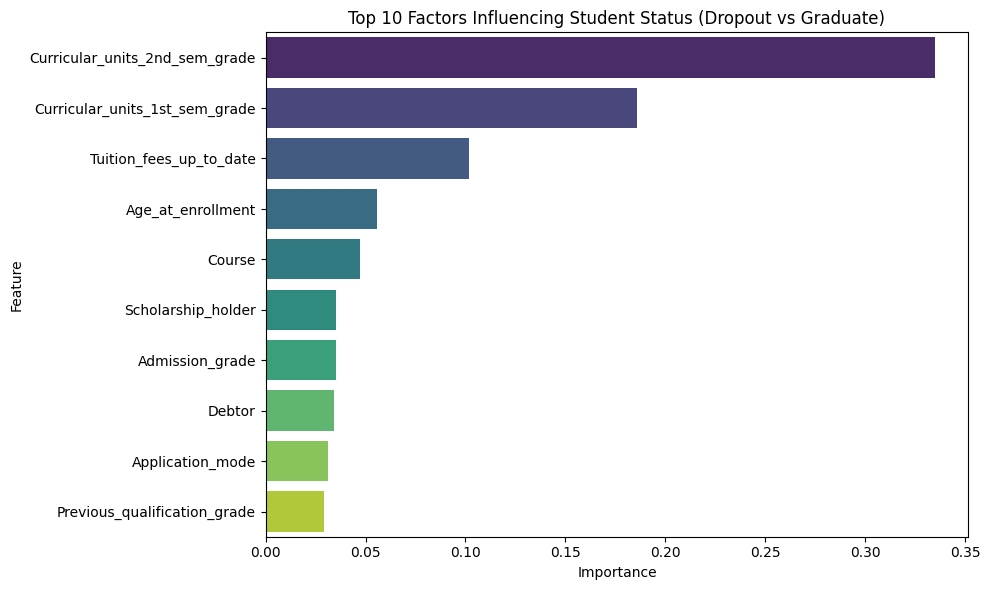


PREDIKSI DATA ENROLLED (Inferensi)
Jumlah data Enrolled yang diprediksi: 794

Distribusi prediksi untuk data Enrolled:
Predicted_Status
Graduate    527
Dropout     267
Name: count, dtype: int64

Sample prediksi (5 data pertama):
   Predicted_Status  Probability
16         Graduate     0.550057
19         Graduate     0.741610
21         Graduate     0.783334
25         Graduate     0.582087
27         Graduate     0.928270


In [7]:
print("="*50)
print("EVALUATION")
print("="*50)

# 1. Classification Report 
print("\n1. CLASSIFICATION REPORT:")
print("-"*30)
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
print("\n2. CONFUSION MATRIX:")
print("-"*30)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dropout', 'Graduate'],
            yticklabels=['Dropout', 'Graduate'])
plt.title('Confusion Matrix - Dropout vs Graduate')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Feature Importance
print("\n3. FEATURE IMPORTANCE:")
print("-"*30)
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Factors Influencing Student Status (Dropout vs Graduate)')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("PREDIKSI DATA ENROLLED (Inferensi)")
print("="*50)

df_enrolled = df[df['Status'] == 'Enrolled'].copy()
if len(df_enrolled) > 0:
    X_enrolled = df_enrolled[selected_features].copy()
    for col in categorical_cols:
        X_enrolled[col] = le.fit_transform(X_enrolled[col])
    X_enrolled_scaled = scaler.transform(X_enrolled)
    
    pred_enrolled = rf.predict(X_enrolled_scaled)
    pred_proba = rf.predict_proba(X_enrolled_scaled)
    
    df_enrolled['Predicted_Status'] = pred_enrolled
    df_enrolled['Probability'] = pred_proba.max(axis=1)
    
    print(f"Jumlah data Enrolled yang diprediksi: {len(df_enrolled)}")
    print("\nDistribusi prediksi untuk data Enrolled:")
    print(df_enrolled['Predicted_Status'].value_counts())
    
    print("\nSample prediksi (5 data pertama):")
    print(df_enrolled[['Predicted_Status', 'Probability']].head())
else:
    print("Tidak ada data Enrolled untuk diprediksi")